# Comparing Posteriors for Burst Model

## Imports

In [121]:
import h5py
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [122]:
def retrieve_data(z):

    folder = rf"D:\Users\nina\Star_Formation_Histories\fitting_delta\posteriors\burst\z_{z}"
    files = sorted(glob.glob(os.path.join(folder, "*.h5")))

    params = [ "age", "massformed", "metallicity", "Av", "logU"]    

    data_list = []

    for fpath in files:

        fname = os.path.basename(fpath)

        # Skip sampler files (those with "_")
        if "_" in fname:
            continue

        age_label = fname.replace(".h5", "")

        with h5py.File(fpath, "r") as f:
            median = f["median"][:]       # shape (6,)
            conf_int = f["conf_int"][:]   # shape (2,6)

        row = {
            "true_age": float(age_label)
        }

        for i, p in enumerate(params):
            row[f"{p}_median"] = median[i]
            row[f"{p}_lower"] = conf_int[0, i]
            row[f"{p}_upper"] = conf_int[1, i]

        data_list.append(row)

    df = pd.DataFrame(data_list)
    df = df.sort_values("true_age")

    return df

In [123]:
def plot_mass_recovery(df, true_mass=10.0):

    ages = df["true_age"]

    mass_median = df["massformed_median"]
    mass_lower = df["massformed_lower"]
    mass_upper = df["massformed_upper"]

    mass_frac_median = mass_median / true_mass
    mass_frac_lower = mass_lower / true_mass
    mass_frac_upper = mass_upper / true_mass

    err_lower = mass_frac_median - mass_frac_lower
    err_upper = mass_frac_upper - mass_frac_median

    plt.figure(figsize=(8,5))

    plt.errorbar(
        ages,
        mass_frac_median,
        yerr=[err_lower, err_upper],
        fmt="o",
        capsize=3,
        label="Recovered / True Mass",
        color="blue"
    )

    plt.axhline(1.0, linestyle="--", label="True Mass Fraction = 1", color="gray")

    plt.xlabel("Age [Gyr]")
    plt.ylabel("Recovered Mass Formed / True Mass")
    plt.title("Recovered Stellar Mass Fraction vs Age")

    plt.xscale("log")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [124]:
def plot_mass_logres_vs_age_allz(dfs, z_vals, true_mass=10.0):

    plt.figure(figsize=(8,5))

    for df, z in zip(dfs, z_vals):

        true_age = df["true_age"]
        recovered = df["massformed_median"]

        # --- log residual ---
        delta_log = np.log10(recovered) - np.log10(true_mass)

        # --- log-space errors ---
        log_err_lower = np.log10(recovered) - np.log10(df["massformed_lower"])
        log_err_upper = np.log10(df["massformed_upper"]) - np.log10(recovered)

        plt.errorbar(
            true_age,
            delta_log,
            yerr=[log_err_lower, log_err_upper],
            fmt="o",
            capsize=3,
            label=f"z={z}",
            alpha=0.8
        )

    plt.axhline(0, linestyle="--", color="gray")

    plt.xlabel("True Age [Gyr]")
    plt.ylabel(r"$\Delta \log(M_*)$ [dex]")

    plt.xscale("log")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [125]:
def compute_age_chi2(df):

    true = df["true_age"].values
    recovered = df["age_median"].values

    # approximate symmetric error
    err = (df["age_upper"].values - df["age_lower"].values) / 2

    chi2 = np.sum(((recovered - true) / err)**2)

    dof = len(true) - 1
    chi2_reduced = chi2 / dof

    return chi2, chi2_reduced

In [126]:
def compute_mass_chi2(df, true_mass=10.0):

    mass_median = df["massformed_median"].values
    mass_lower = df["massformed_lower"].values
    mass_upper = df["massformed_upper"].values

    frac = mass_median / true_mass
    frac_err = (mass_upper - mass_lower) / (2 * true_mass)

    expected = np.ones_like(frac)

    chi2 = np.sum(((frac - expected) / frac_err)**2)

    dof = len(frac) - 1
    chi2_reduced = chi2 / dof

    return chi2, chi2_reduced

In [127]:
def compute_mass_chi2_clean(df, true_mass=10.0, min_age=0.001, err_floor=0.02):

    # --- remove problematic very young ages ---
    df = df[df["true_age"] > min_age]

    log_true = np.log10(true_mass)

    log_median = np.log10(df["massformed_median"].values)
    log_lower  = np.log10(df["massformed_lower"].values)
    log_upper  = np.log10(df["massformed_upper"].values)

    # --- symmetric log error ---
    log_err = (log_upper - log_lower) / 2

    # --- apply error floor (dex) ---
    log_err = np.maximum(log_err, err_floor)

    # --- chi2 ---
    chi2 = np.sum(((log_median - log_true) / log_err)**2)

    dof = len(log_median)   # no fitted parameter
    chi2_red = chi2 / dof

    return chi2, chi2_red

In [128]:
def compute_age_chi2_clean(df):

    # --- remove problematic very young ages ---
    df = df[df["true_age"] > 0]

    log_true = np.log10(df["true_age"].values)

    log_median = np.log10(df["age_median"].values)
    log_lower  = np.log10(df["age_lower"].values)
    log_upper  = np.log10(df["age_upper"].values)

    # --- symmetric log error ---
    log_err = (log_upper - log_lower) / 2

    # --- chi2 ---
    chi2 = np.sum(((log_median - log_true) / log_err)**2)

    dof = len(log_median)
    chi2_red = chi2 / dof

    return chi2, chi2_red

In [129]:
import matplotlib.pyplot as plt

def plot_age_recovery(df):

    ages = df["true_age"]

    age_median = df["age_median"]
    age_lower = df["age_lower"]
    age_upper = df["age_upper"]

    err_lower = age_median - age_lower
    err_upper = age_upper - age_median

    plt.figure(figsize=(8,5))

    plt.errorbar(
        ages,
        age_median,
        yerr=[err_lower, err_upper],
        fmt="o",
        capsize=3,
        label="Recovered Age",
        color="deeppink"
    )

    plt.plot(
        ages,
        ages,
        linestyle="--",
        color="gray",
        label="1:1 Line"
    )

    plt.xlabel("True Age [Gyr]")
    plt.ylabel("Recovered Age")
    plt.title("Recovered Stellar Age vs True Age")

    plt.xscale("log")
    plt.yscale("log")   

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [130]:
def plot_age_recovery_logres_allz(dfs, z_vals):

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(7,8),
        sharex=True,
        gridspec_kw={"height_ratios": [2,1]}
    )

    for df, z in zip(dfs, z_vals):

        true_age = df["true_age"]
        recovered = df["age_median"]

        err_lower = recovered - df["age_lower"]
        err_upper = df["age_upper"] - recovered

        ax1.errorbar(
            true_age,
            recovered,
            yerr=[err_lower, err_upper],
            fmt="o",
            capsize=3,
            label=f"z={z}",
            alpha=0.8
        )

        delta_log = np.log10(recovered) - np.log10(true_age)

        log_err_lower = np.log10(recovered) - np.log10(df["age_lower"])
        log_err_upper = np.log10(df["age_upper"]) - np.log10(recovered)

        ax2.errorbar(
            true_age,
            delta_log,
            yerr=[log_err_lower, log_err_upper],
            fmt="o",
            capsize=3,
            alpha=0.8
        )

    x = true_age

    ax1.plot(x, x, "--", color="gray")

    ax2.axhline(0, linestyle="--", color="gray")

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax2.set_xscale("log")

    ax1.set_ylabel("Recovered Age [Gyr]")
    ax2.set_ylabel(r"$\Delta \log(\mathrm{Age})$ [dex]")
    ax2.set_xlabel("True Age [Gyr]")

    ax1.legend()
    ax1.grid(alpha=0.3)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [131]:
df_z2 = retrieve_data(2)
df_z3 = retrieve_data(3)
df_z4 = retrieve_data(4)
df_z5 = retrieve_data(5)
df_z6 = retrieve_data(6)
df_z7 = retrieve_data(7)
df_z8 = retrieve_data(8)

## Mass Comparison

### z = 2

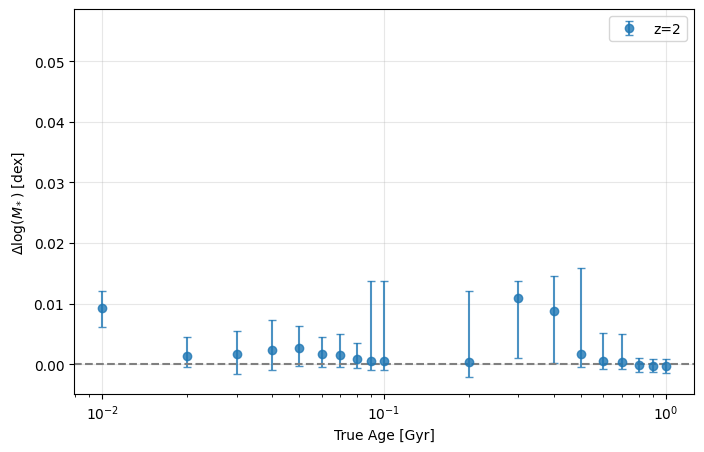

In [132]:
plot_mass_logres_vs_age_allz([df_z2], [2])


### z = 3

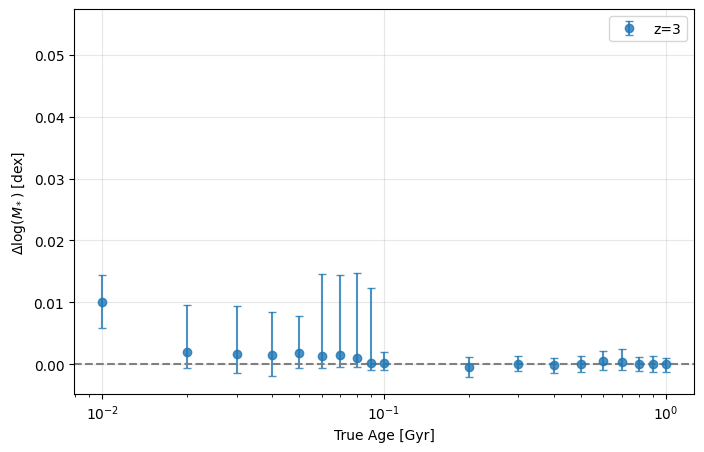

In [133]:
plot_mass_logres_vs_age_allz([df_z3], [3])

### z = 4

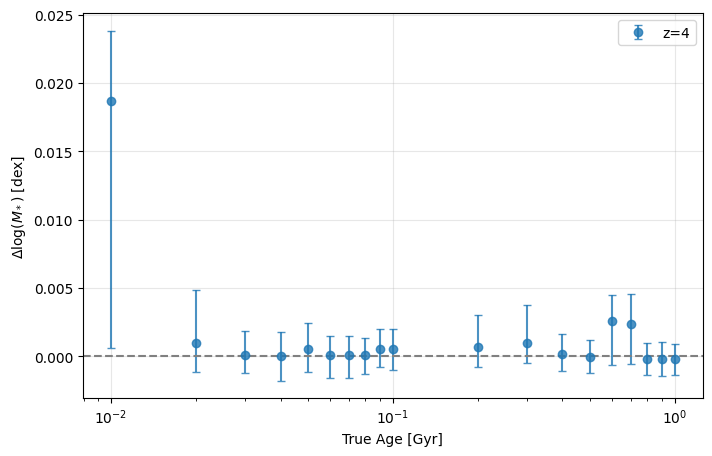

In [134]:
plot_mass_logres_vs_age_allz([df_z4], [4])

### z = 5

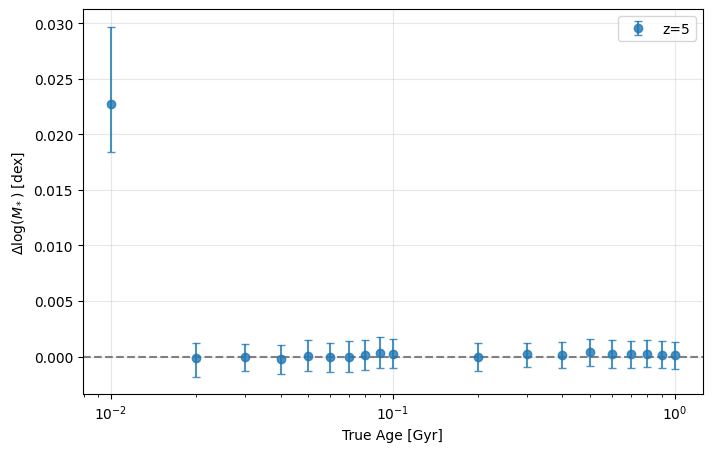

In [135]:
plot_mass_logres_vs_age_allz([df_z5], [5])

### z = 6

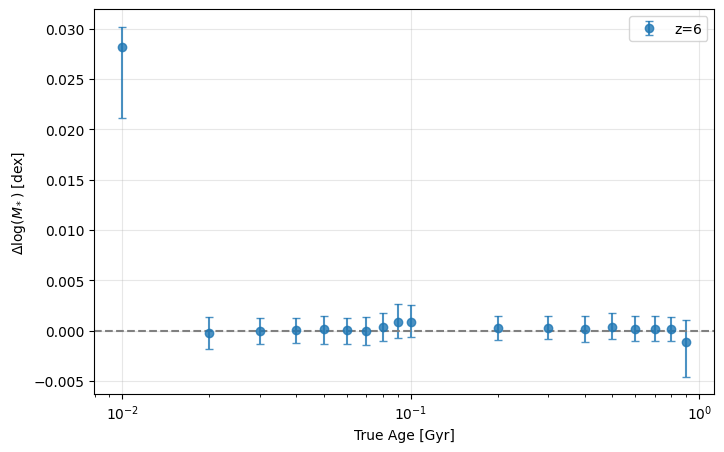

In [136]:
plot_mass_logres_vs_age_allz([df_z6], [6])

### z = 7

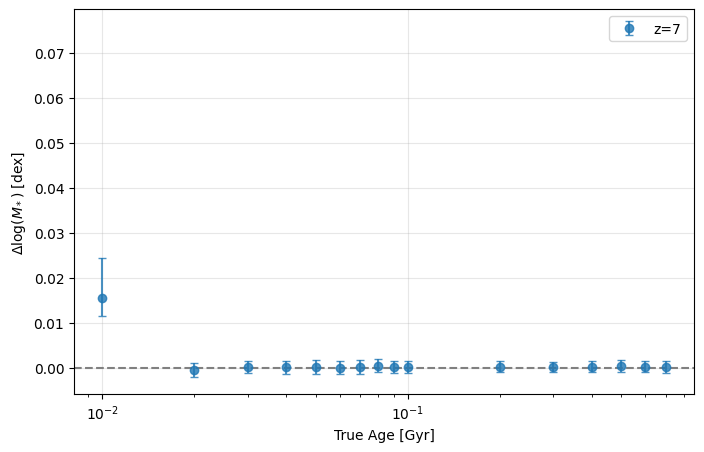

In [137]:
plot_mass_logres_vs_age_allz([df_z7], [7])

### z = 8

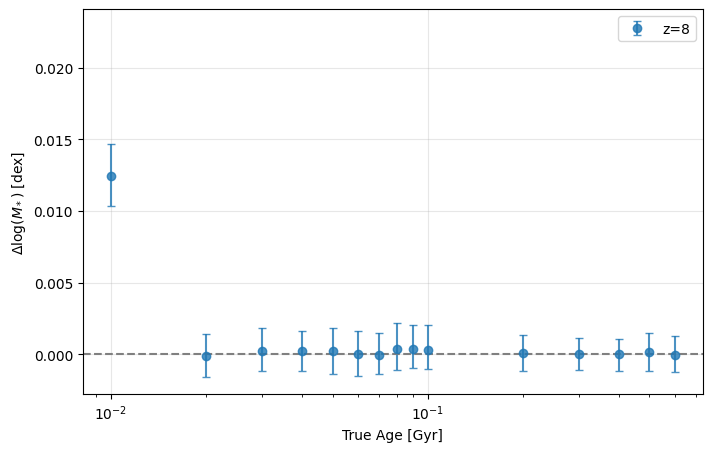

In [138]:
plot_mass_logres_vs_age_allz([df_z8], [8])

## Age Comparison

### z = 2

d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


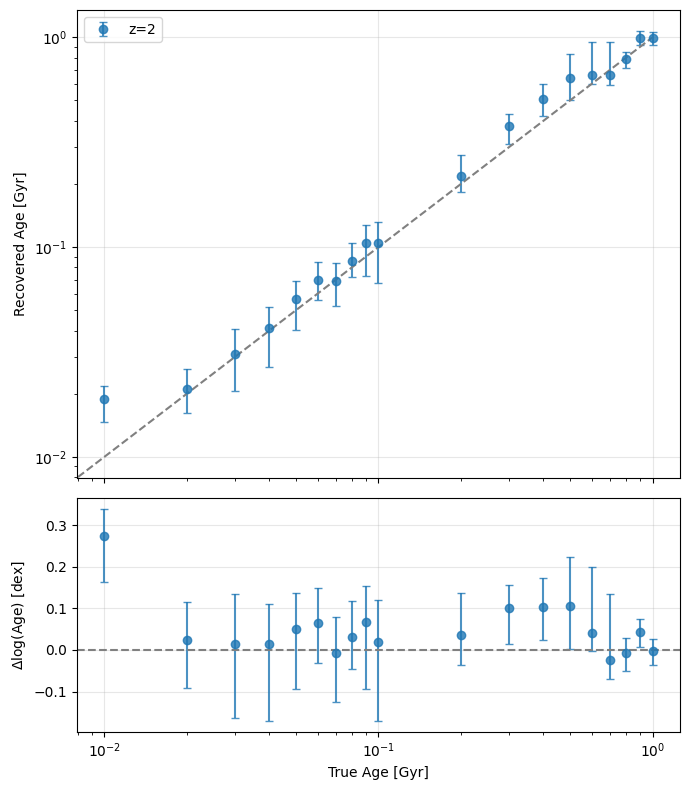

In [139]:
plot_age_recovery_logres_allz([df_z2], [2])

### z = 3

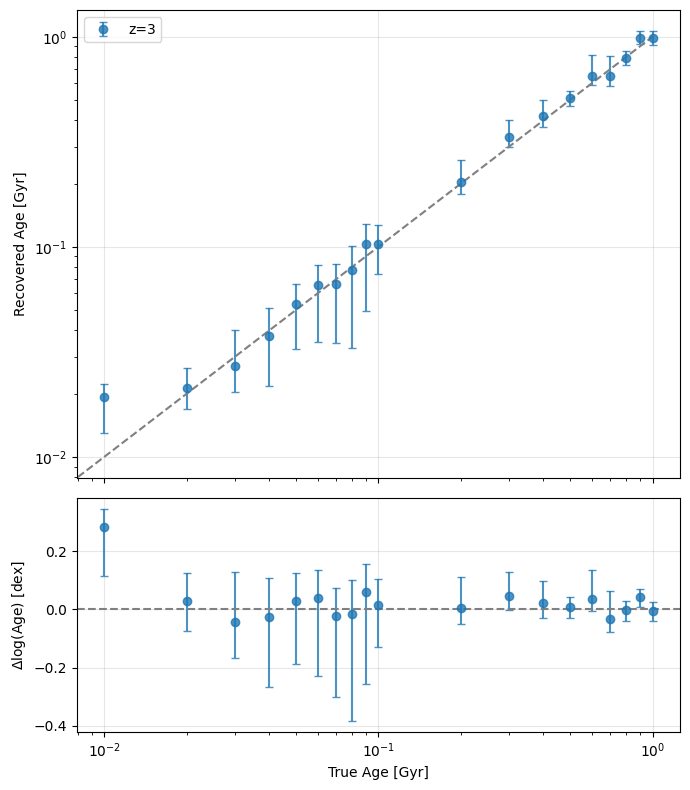

In [140]:
plot_age_recovery_logres_allz([df_z3], [3])

### z = 4

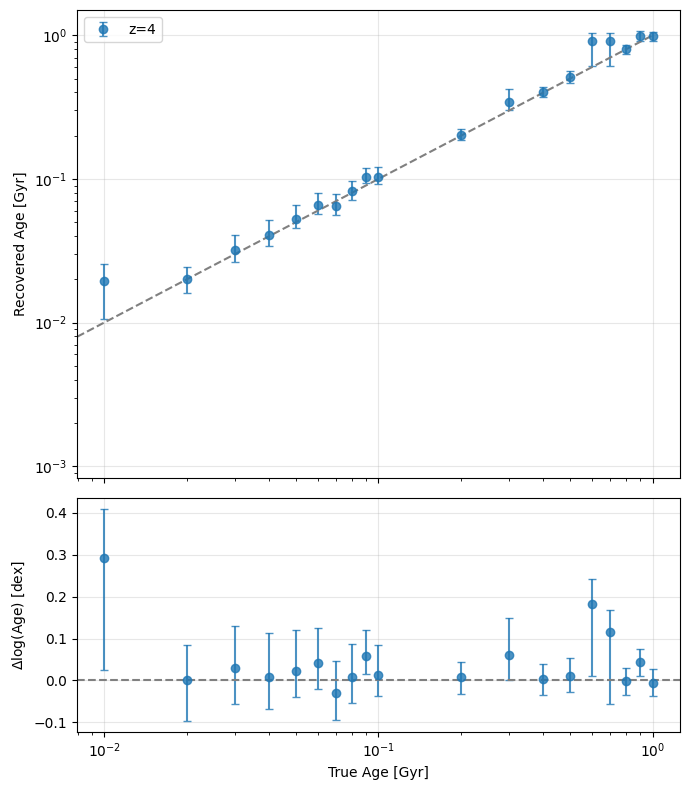

In [141]:
plot_age_recovery_logres_allz([df_z4], [4])

### z = 5

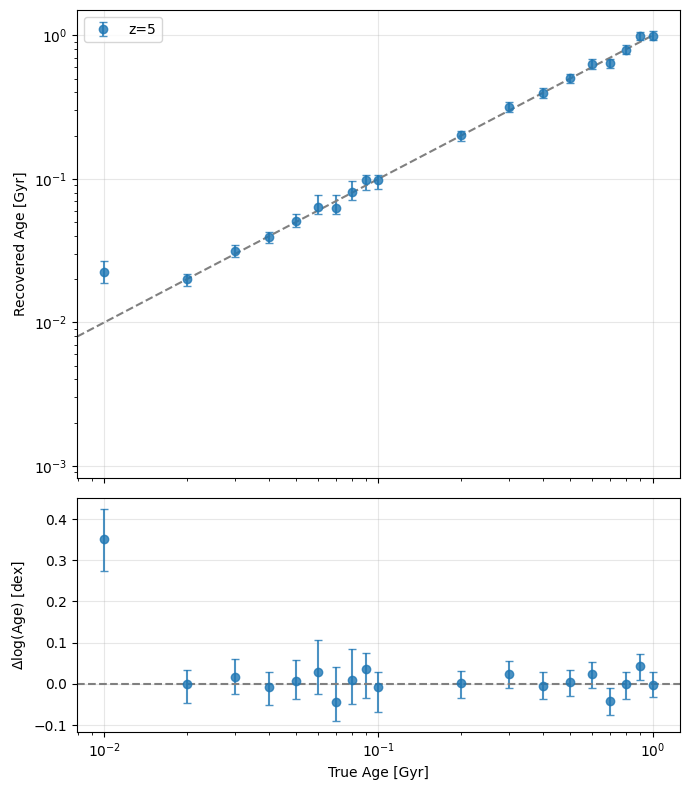

In [142]:
plot_age_recovery_logres_allz([df_z5], [5])

### z = 6

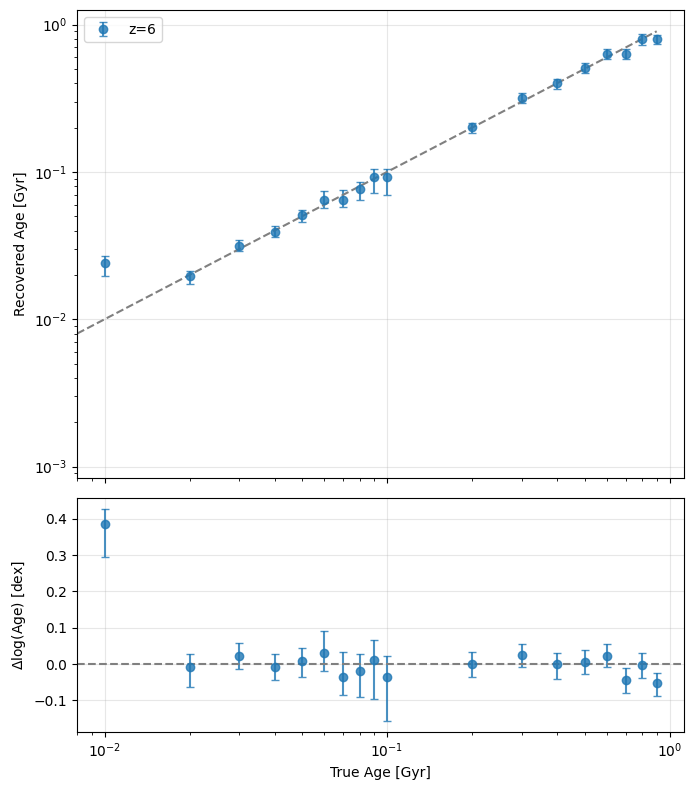

In [143]:
plot_age_recovery_logres_allz([df_z6], [6])

### z = 7

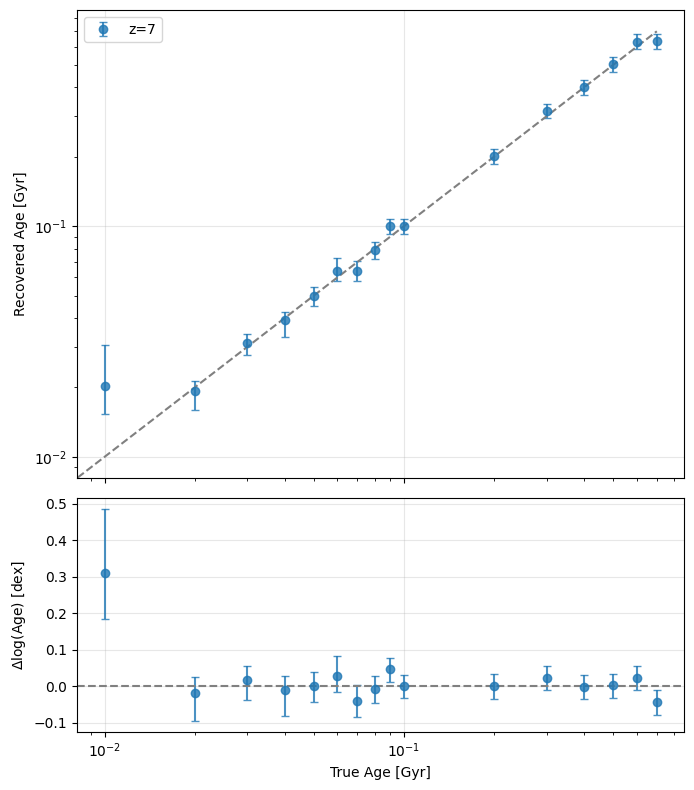

In [144]:
plot_age_recovery_logres_allz([df_z7], [7])

### z = 8

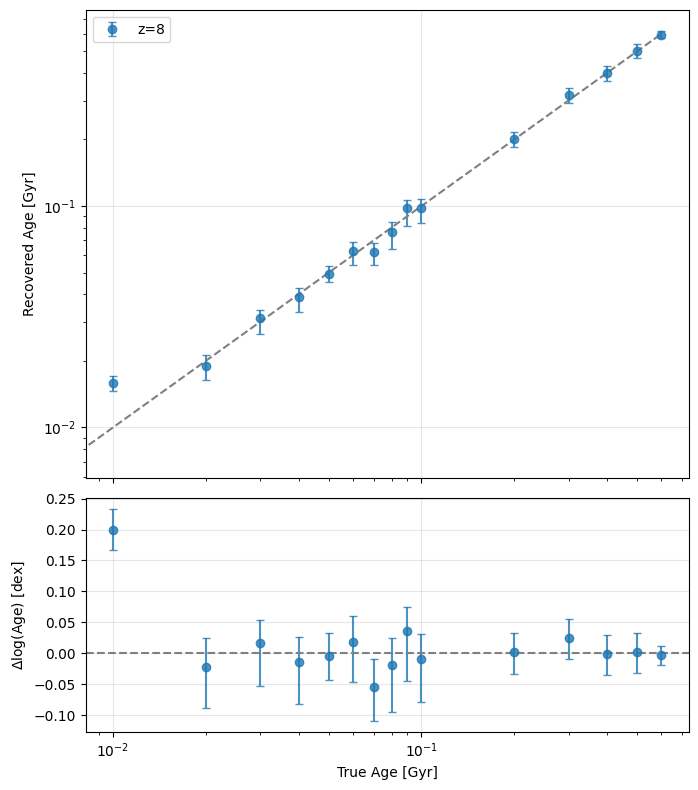

In [145]:
plot_age_recovery_logres_allz([df_z8], [8])

# Computing chi squared

In [146]:
z_vals = [2,3,4,5,6,7,8]
dfs = [df_z2, df_z3, df_z4, df_z5, df_z6, df_z7, df_z8]

age_chi2 = []
mass_chi2 = []

for df in dfs:

    _, red_age = compute_age_chi2_clean(df)
    _, red_mass = compute_mass_chi2_clean(df)

    age_chi2.append(red_age)
    mass_chi2.append(red_mass)

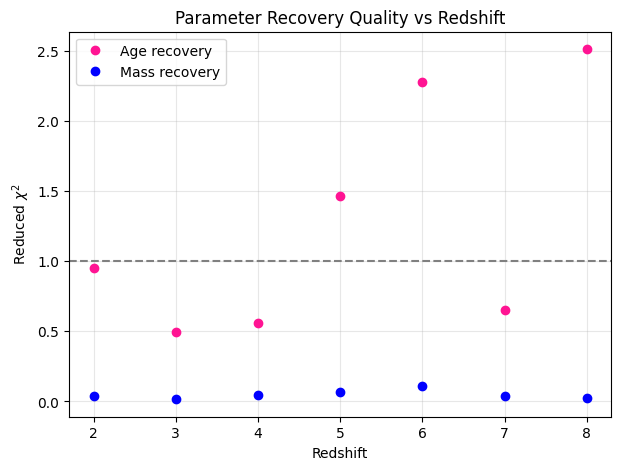

In [147]:
plt.figure(figsize=(7,5))

plt.plot(z_vals, age_chi2, "o", label="Age recovery", color = "deeppink")
plt.plot(z_vals, mass_chi2, "o", label="Mass recovery", color = "blue")

plt.axhline(1, linestyle="--", color="gray")

plt.xlabel("Redshift")
plt.ylabel("Reduced $\chi^2$")
plt.title("Parameter Recovery Quality vs Redshift")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Multi-redshift plots

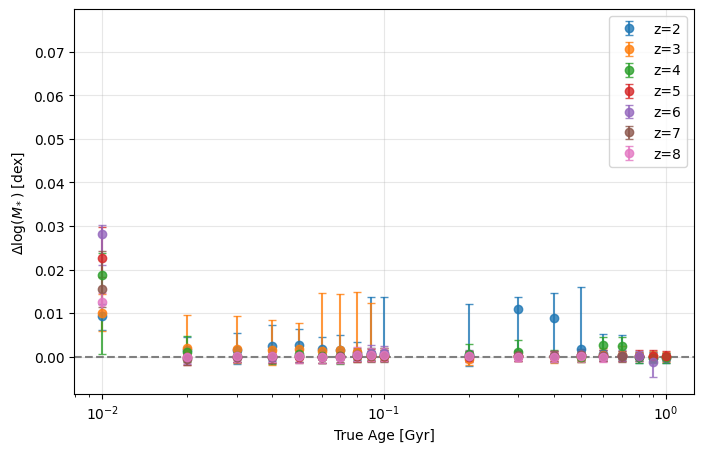

In [148]:
plot_mass_logres_vs_age_allz(dfs, z_vals)

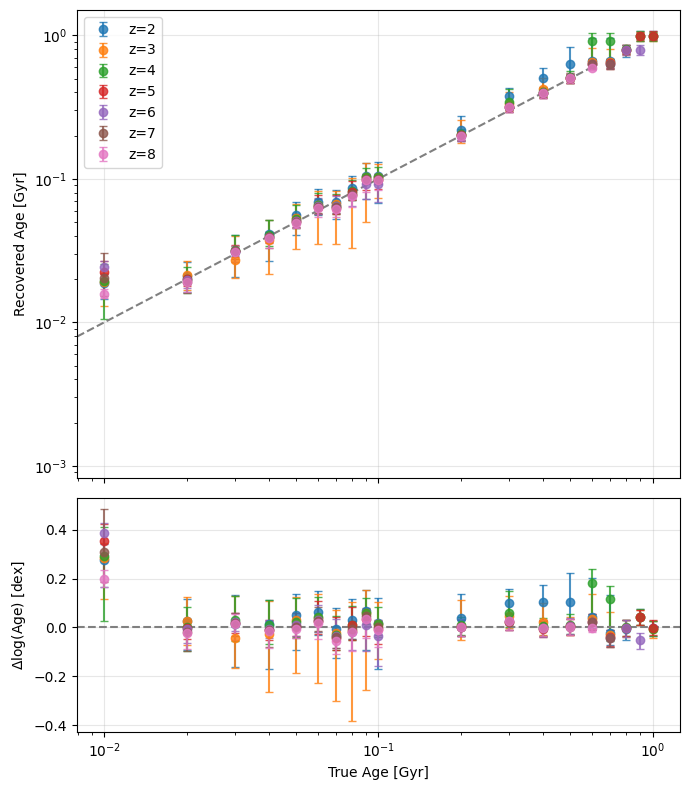

In [149]:
plot_age_recovery_logres_allz(dfs, z_vals)